<h2>Assignment 1</h2>

<table style="width:100%; text-align:left;">
<tr>
<td>

### Student 1  
**Name:** Aakanksha Deshpande  
**Student Id:** 25238088  

</td>

<td>

### Student 2  
**Name:** Vijayalaxmi Hubli  
**Student Id:** 25242017  

</td>
</tr>
</table>


## Task 1: Implement Logistic Regression

In [1]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Display plots inline
%matplotlib inline

In [3]:
# Initialising Hyperparameters

# alpha = 0.0001 # learning rate
# max_iterations = 10000
# threshold = 1e-8
# N = 500 # No of iterations

In [4]:
# Sigmoid Function (Activation Function)
def sigmoid(z):
    return (1 / (1 + (np.exp(-z))))

In [5]:
# Loss function
def compute_loss(y, y_hat):
    return (- (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))).item()

In [6]:
# Implementing Logistic Regression Algorithm

def train_logistic_regression(X, Y, alpha, max_iteration, threshold):
    """
    Logistic Regression Learning Algorithm with forward pass and Stochastic Gradient Descent

    Inputs:
    X = training dataset
    Y = target labels
    alpha = learning rate
    max_iteration = no of steps allowed for training
    threshold = stopping criteris
    N = no of iterations to accumulate the loss to check convergence

    Outputs:
    w = learned weights
    b = learned bias
    """
    #---------------------------------
    # Initialising weights and biases
    #---------------------------------
    stopping = False
    J_running = 0
    epoch_number = 0
    J_running_prev = 0
    prev_avg_loss = float("inf")
    iteration = 0
    N,m = X.shape
    w = np.random.normal(0, 0.01, size=(m,1))
    b = 0.01


    #---------------------------------
    # Implementing SGD
    #---------------------------------
    loss = []
    epoch_loss = []
    while not stopping:

        # picking random values from training dataset
        index = np.random.randint(0, N)
        x_i = X[index].reshape(-1,1)
        y_i = Y[index]

        # Implementing Forward propagation stage
        z = np.dot(w.T, x_i) + b
        y_hat = sigmoid(z)

        # Calculate the loss
        J_current = compute_loss(y_i, y_hat)
        loss.append(J_current)
        # Gradient Descent stage:
        # partial deivatives
        dw = (y_hat - y_i) * x_i
        db = y_hat - y_i

        # calculate w and b
        w -= alpha * dw
        b -= alpha * db

        # Checking stopping criteia
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            epoch_number += 1
            avg_loss = J_running / N
            epoch_loss.append(avg_loss)
            # print("Iteration:", iteration, "Avg Loss:", avg_loss)
            if abs(avg_loss - prev_avg_loss) < threshold:
                print(f"Converged after {epoch_number} epochs ({iteration} iterations)")
                stopping = True
            prev_avg_loss = avg_loss
            J_running = 0
        if iteration  > max_iteration:
            print("Failed to converge!!!")
            stopping = True # Failed to converge
        


    return w, b, loss, epoch_loss


In [7]:
def predict(X, w, b, threshold):
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= threshold).astype(int)

## Task 2: Testing on Datasets

In [8]:
def split_data(X, y, random_state = 42):
    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y)

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp, Y_temp, test_size=0.5, random_state=random_state, stratify=Y_temp)

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [9]:
# Loading Dataset 1
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("/Users/aakankshadeshpande/Documents/Assignments_Sem2/blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [10]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


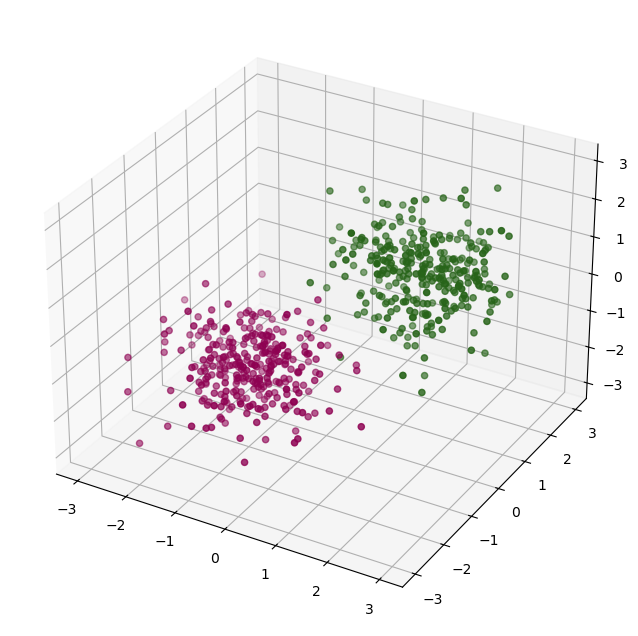

In [11]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

In [15]:
X_train1, Y_train1, X_val1, Y_val1, X_test1, Y_test1 = split_data(X1, y1)
w1, b1, loss1, epoch_loss1 = train_logistic_regression(X_train1, Y_train1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(w1, b1, epoch_loss1)

Converged after 14 epochs (5880 iterations)
[[1.9786357 ]
 [1.6586087 ]
 [1.78770993]] [[0.01458753]] [0.2434289843008049, 0.09425122717883971, 0.058437033457003865, 0.05304906332202178, 0.03561253780398906, 0.03976115456470483, 0.030419088530195267, 0.026563401319684796, 0.029277495856349058, 0.02491955222755306, 0.019400256089254324, 0.028854063176242936, 0.02754177068755904, 0.028285031578713225]


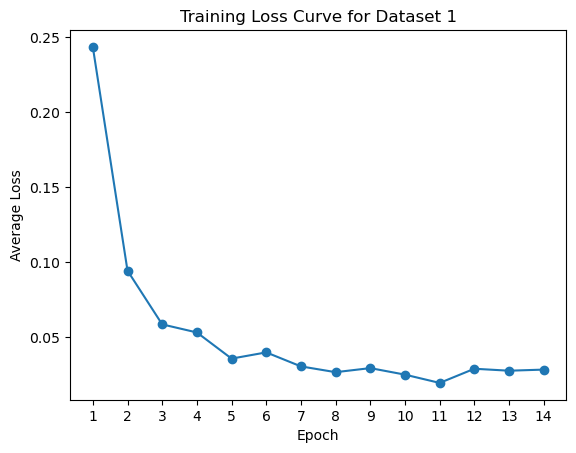

In [16]:
# plotting the Avg_Loss v/s Epoch
plt.plot(range(1, len(epoch_loss1)+1), epoch_loss1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 1")
plt.xticks(range(1, len(epoch_loss1)+1))
plt.show()

In [17]:
# Validate and test performance
y1_val_pred = predict(X_val1, w1, b1, threshold = 0.5)
val_accuracy = np.mean(y1_val_pred == Y_val1) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")
    
y1_test_pred = predict(X_test1, w1, b1, threshold = 0.5)
test_accuracy = np.mean(y1_test_pred == Y_test1) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Validation Accuracy: 50.00%
Test Accuracy: 50.00%


In [7]:
# Loading Dataset 2
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv(r"C:\Users\anush\Downloads\circles500 (1).csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [8]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


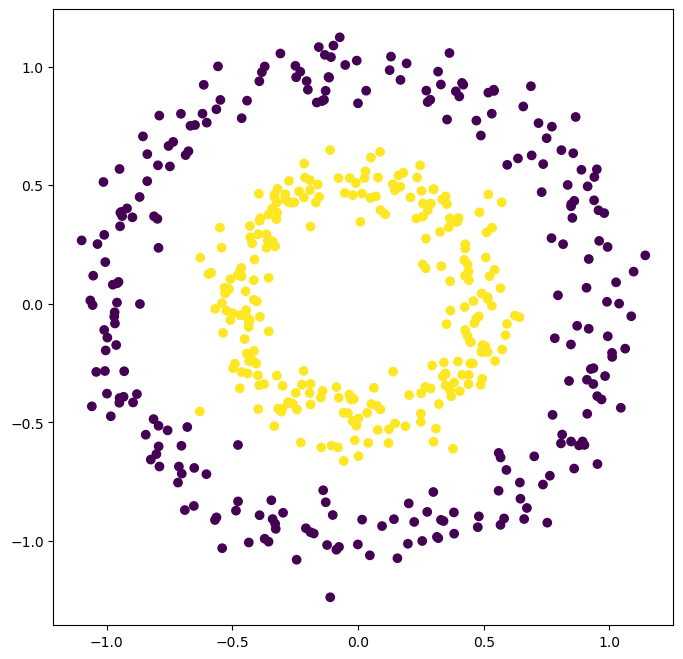

In [9]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

In [24]:
X_train2, Y_train2, X_val2, Y_val2, X_test2, Y_test2 = split_data(X2, y2)
w2, b2, loss2, epoch_loss2 = train_logistic_regression(X_train2, Y_train2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(w2, b2, epoch_loss2)

Converged after 16 epochs (5600 iterations)
[[ 0.00627377]
 [-0.15200317]] [[-0.04894039]] [0.6939226251635067, 0.6951803302323695, 0.6936505431065736, 0.6906804826883011, 0.6938775367867387, 0.6965991881317481, 0.6936016270138075, 0.6916698627651515, 0.6903870460966226, 0.6960222295355575, 0.6906345668545321, 0.6979819937583067, 0.6945168956953424, 0.6892657400098093, 0.6951300369521002, 0.6948664240805069]


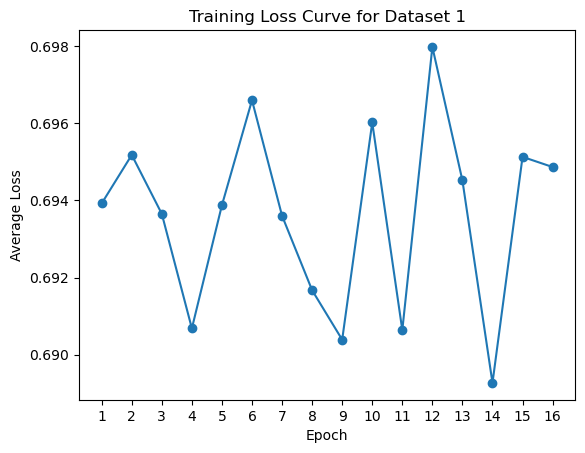

In [25]:
# plotting the Avg_Loss v/s Epoch
plt.plot(range(1, len(epoch_loss2)+1), epoch_loss2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 1")
plt.xticks(range(1, len(epoch_loss2)+1))
plt.show()

In [28]:
# Validate and test performance
y2_val_pred = predict(X_val2, w2, b2, threshold = 1e-3)
val_accuracy = np.mean(y2_val_pred == Y_val2) * 100
print(f"Validation Accuracy: {val_accuracy:.2f}%")

y2_test_pred = predict(X_test2, w2, b2, threshold = 1e-3)
test_accuracy = np.mean(y2_test_pred == Y_test2) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Validation Accuracy: 50.67%
Test Accuracy: 49.33%


## Task 3: Implement and test a shallow Neural Network

## Task 4: Tackle a challenging task

## Task 5: Deep Learning Enhancements